# Corporate Credit Risk Analysis: Ratio Scoring, Monte Carlo & Merton Models

This project scores the credit quality of **10 Indian companies** using their financial ratios, then stress-tests those scores with a **Monte Carlo simulation** and checks the results against their real **CRISIL/ICRA ratings**. It also builds a separate market-based **Merton model** as a cross-check.

The main result: ranking firms by their **simulated downside (VaR)** lined up with the actual agency ratings much better than ranking by their central score — the correlation went from **0.32 to 0.74**. That suggests **the agencies may be weighting worst-case risk more than average financial condition**, though with only 10 firms this is a signal, not proof.

## Module 1: Data

10 non-financial rated Indian firms spanning **AAA to A−**, five years of financials, four ratios each: leverage (debt-to-assets), interest coverage, liquidity, and profitability (ROCE).

One thing to note on leverage: I used **debt-to-assets instead of debt-to-equity**. D/E blows up when equity is near zero and flips negative when equity is negative, which broke it for 2 firms (IndiGo and Vodafone Idea). I kept the D/E column in the data anyway as a record of where it failed.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('credit_data.csv')

print(df.shape)
print(df.dtypes)
df.head(50)

(50, 10)
Firm              object
Year               int64
Borrowings         int64
total_assets       int64
debt_equity      float64
debt_assets      float64
int_coverage     float64
current_ratio    float64
roce               int64
credit_rating     object
dtype: object


,Firm,Year,Borrowings,total_assets,debt_equity,debt_assets,int_coverage,current_ratio,roce,credit_rating
0,Reliance,2021,278962,1320065,0.398419,0.211324,3.812827,1.0,8,AAA
1,Reliance,2022,319158,1498622,0.409447,0.212968,7.445214,1.1,8,AAA
2,Reliance,2023,451664,1605882,0.630928,0.281256,7.271882,1.1,9,AAA
3,Reliance,2024,350719,1755048,0.442001,0.199834,7.029068,1.1,10,AAA
4,Reliance,2025,374313,1949713,0.443920,0.191984,6.823437,1.0,10,AAA
5,UltraTech,2021,21719,86176,0.491658,0.252031,7.784657,1.2,15,AAA
6,UltraTech,2022,11299,83811,0.224026,0.134815,12.184127,1.0,14,AAA
7,UltraTech,2023,11058,91380,0.203553,0.121011,12.904010,1.0,13,AAA
8,UltraTech,2024,11403,100797,0.189331,0.113128,13.408058,0.8,15,AAA
9,UltraTech,2025,24102,133632,0.340871,0.180361,7.751060,0.7,11,AAA


## Module 2: Credit Scoring

I score each firm on **FY2025** ratios (the latest year, so it lines up with their current ratings). Each ratio gets z-scored so the four different scales become comparable, then they're weighted and summed into one score. Leverage and coverage get 30% each, liquidity and profitability 20% each, since debt-servicing ability matters most for credit.

Two fixes here: I take the **log of interest coverage** first, because it's badly right-skewed (Asian Paints covers its interest 26x, which otherwise dominates everything). And I **flip the sign on leverage** (`lev_inv`) so all four ratios point the same way — higher = safer.

In [2]:
d = df[df.Year == 2025].copy().reset_index(drop=True)

d['log_cov'] = np.log(d['int_coverage'])
d['lev_inv'] = -d['debt_assets']

factors = ['lev_inv', 'log_cov', 'current_ratio', 'roce']
print(d[['Firm'] + factors].round(2).to_string(index=False))

         Firm  lev_inv  log_cov  current_ratio  roce
     Reliance    -0.19     1.92            1.0    10
    UltraTech    -0.18     2.05            0.7    11
 Asian Paints    -0.08     3.28            2.3    26
Bharti Airtel    -0.42     1.42            0.3    13
   Tata Steel    -0.34     1.24            0.6     9
      Vedanta    -0.46     1.49            0.6    12
   Tata Power    -0.40     0.97            0.5    11
       Indigo    -0.58     1.26            1.5    17
       Suzlon    -0.02     1.99            1.4    33
Vodafone Idea    -1.18    -0.31            0.6    -2


In [3]:
for c in factors:
    d['z_' + c] = (d[c] - d[c].mean()) / d[c].std()

zcols = ['z_' + c for c in factors]

weights = np.array([0.30, 0.30, 0.20, 0.20])
d['score'] = (d[zcols].values * weights).sum(axis=1)

d['rank'] = d['score'].rank(ascending=False).astype(int)

print(d[['Firm', 'credit_rating', 'score', 'rank']].sort_values('rank').round(2).to_string(index=False))

         Firm credit_rating  score  rank
 Asian Paints           AAA   1.54     1
       Suzlon            A+   1.02     2
     Reliance           AAA   0.24     3
    UltraTech           AAA   0.21     4
       Indigo           AA-  -0.02     5
      Vedanta            AA  -0.23     6
   Tata Steel           AA+  -0.28     7
Bharti Airtel           AAA  -0.30     8
   Tata Power           AA+  -0.41     9
Vodafone Idea            A-  -1.77    10


## Module 3: Monte Carlo Simulation

A single score hides how much uncertainty is behind it. So here I turn each firm's one score into a spread of 10,000 possible scores, based on how much its ratios actually move.

For each firm I set up two things: the **center** (its FY2025 values, where it stands now) and the **spread** (the standard deviation of its ratios over 5 years, how much it bounces around). Using the 5-year average as the center would be wrong — Suzlon's average leverage looks bad because it was drowning in debt in 2021, but it's basically debt-free now, so I center on the current year and use history only for the spread.

In [4]:
hist = df.copy()
hist['cov_floored'] = hist['int_coverage'].clip(lower=0.1)
hist['log_cov'] = np.log(hist['cov_floored'])
hist['lev_inv'] = -hist['debt_assets']

sigma = hist.groupby('Firm')[factors].std()
mu = hist[hist.Year == 2025].set_index('Firm')[factors]

print("=== CENTER (FY2025) ===")
print(mu.round(3))
print("\n=== SPREAD (5-yr std) ===")
print(sigma.round(3))

=== CENTER (FY2025) ===
               lev_inv  log_cov  current_ratio  roce
Firm                                                
Reliance        -0.192    1.920            1.0    10
UltraTech       -0.180    2.048            0.7    11
Asian Paints    -0.075    3.276            2.3    26
Bharti Airtel   -0.423    1.415            0.3    13
Tata Steel      -0.344    1.237            0.6     9
Vedanta         -0.458    1.488            0.6    12
Tata Power      -0.402    0.974            0.5    11
Indigo          -0.579    1.257            1.5    17
Suzlon          -0.025    1.989            1.4    33
Vodafone Idea   -1.179   -0.307            0.6    -2

=== SPREAD (5-yr std) ===
               lev_inv  log_cov  current_ratio    roce
Firm                                                  
Asian Paints     0.011    0.280          0.071   4.712
Bharti Airtel    0.032    0.115          0.114   2.490
Indigo           0.093    1.682          0.219  17.544
Reliance         0.036    0.282       

### Correlation and Cholesky

The four ratios aren't independent. When a firm takes on more debt, its interest coverage tends to fall too. So if I simulate them separately, I end up creating scenarios that can't actually happen.

You can see this in the correlation matrix below. **Interest coverage and ROCE come out at 0.88**, which makes sense because both are calculated from operating profit. To keep the simulated ratios moving together properly, I run the correlation matrix through **Cholesky decomposition**. It works like a square root for matrices, and once I multiply my random numbers by it, they come out correlated the way real ratios are. The last line just checks that the decomposition rebuilt the original matrix.

In [5]:
dev = hist.groupby('Firm')[factors].transform(lambda x: x - x.mean())
corr = dev.corr()

print(corr.round(3))

               lev_inv  log_cov  current_ratio   roce
lev_inv          1.000    0.587          0.431  0.405
log_cov          0.587    1.000          0.466  0.878
current_ratio    0.431    0.466          1.000  0.401
roce             0.405    0.878          0.401  1.000


In [6]:
L = np.linalg.cholesky(corr.values)

print("Eigenvalues:", np.round(np.linalg.eigvals(corr.values), 4))
print("\nL (lower triangular):")
print(np.round(L, 3))
print("\nVerify L @ L.T == corr:", np.allclose(L @ L.T, corr.values))

Eigenvalues: [2.6138 0.0955 0.5703 0.7203]

L (lower triangular):
[[1.    0.    0.    0.   ]
 [0.587 0.81  0.    0.   ]
 [0.431 0.263 0.863 0.   ]
 [0.405 0.791 0.021 0.458]]

Verify L @ L.T == corr: True


### Running the simulation

Now I actually run the 10,000 draws. For each firm I generate random numbers, turn them correlated using the Cholesky matrix from above, then shift and scale them to that firm's center and spread. Each draw gives one possible version of the firm's four ratios, which I score the same way as before.

Two small things I had to handle. Leverage can't go positive (a firm can't have negative debt), so I cap those draws. And I keep the scoring scale **fixed to the FY2025 values** across every simulation — otherwise the scores wouldn't be comparable from one run to the next.

In [7]:
Zmu = mu[factors].mean()
Zsd = mu[factors].std()

W = np.array([0.30, 0.30, 0.20, 0.20])
np.random.seed(42)
N = 10000

sims = {}
for fm in mu.index:
    Zi = np.random.normal(0, 1, (N, 4))          # independent
    Zc = Zi @ L.T                                 # -> correlated
    draws = mu.loc[fm].values + sigma.loc[fm].values * Zc
    draws[:, 0] = np.clip(draws[:, 0], None, 0)   # lev_inv <= 0
    z = (draws - Zmu.values) / Zsd.values         # frozen params
    sims[fm] = (z * W).sum(axis=1)

S = pd.DataFrame(sims)

res = pd.DataFrame({
    'M2_point': d.set_index('Firm')['score'],
    'MC_mean': S.mean(),
    'MC_std': S.std(),
    'p5': S.quantile(0.05),
    'p95': S.quantile(0.95)
})
res['drift'] = res.MC_mean - res.M2_point
print(res.sort_values('M2_point', ascending=False).round(3).to_string())

               M2_point  MC_mean  MC_std     p5    p95  drift
Asian Paints      1.544    1.544   0.201  1.212  1.876  0.000
Suzlon            1.020    0.843   0.756 -0.507  1.975 -0.177
Reliance          0.237    0.237   0.141  0.004  0.472 -0.000
UltraTech         0.213    0.214   0.198 -0.110  0.536  0.002
Indigo           -0.023   -0.041   0.976 -1.630  1.553 -0.018
Vedanta          -0.235   -0.235   0.287 -0.705  0.238 -0.001
Tata Steel       -0.276   -0.280   0.412 -0.949  0.402 -0.004
Bharti Airtel    -0.304   -0.304   0.126 -0.509 -0.099  0.000
Tata Power       -0.407   -0.407   0.129 -0.615 -0.192 -0.000
Vodafone Idea    -1.769   -1.769   0.176 -2.059 -1.475  0.001


In [8]:
ranks = S.rank(axis=1, ascending=False)

rank_dist = pd.DataFrame({
    'M2_rank': d.set_index('Firm')['rank'],
    'rank_mean': ranks.mean(),
    'rank_median': ranks.median().astype(int),
    'rank_p5': ranks.quantile(0.05).astype(int),
    'rank_p95': ranks.quantile(0.95).astype(int),
    'pct_top3': (ranks <= 3).mean() * 100,
    'pct_bottom3':(ranks >=8).mean() * 100
})
rank_dist['range'] = rank_dist.rank_p5.astype(str) + ' - ' + rank_dist.rank_p95.astype(str)
rank_dist['skew'] = rank_dist.rank_mean - rank_dist.rank_median

print(rank_dist.sort_values('M2_rank')[['M2_rank','rank_mean','rank_median','skew','range','pct_top3','pct_bottom3']].round(1).to_string())

               M2_rank  rank_mean  rank_median  skew    range  pct_top3  pct_bottom3
Asian Paints         1        1.2            1   0.2    1 - 2     100.0          0.0
Suzlon               2        2.8            2   0.8    1 - 8      79.3          5.9
Reliance             3        3.8            4  -0.2    2 - 5      38.4          0.0
UltraTech            4        4.0            4  -0.0    2 - 6      35.6          0.2
Indigo               5        5.6            5   0.6    1 - 9      36.2         36.5
Vedanta              6        6.5            6   0.5    4 - 9       3.3         28.7
Tata Steel           7        6.6            7  -0.4    3 - 9       7.2         39.8
Bharti Airtel        8        6.9            7  -0.1    5 - 9       0.0         30.8
Tata Power           9        7.6            8  -0.4    6 - 9       0.0         58.1
Vodafone Idea       10       10.0           10  -0.0  10 - 10       0.0        100.0


In [9]:
S.to_csv('mc_scores.csv', index=False)
res.to_csv('mc_summary.csv')
ranks.to_csv('mc_ranks.csv', index=False)
rank_dist.to_csv('rank_dist.csv')

## Module 4: Risk Metrics and Validation

Here I compute two downside measures for each firm from its simulated scores: **VaR** (the 5th-percentile score, the level things only fall below 5% of the time) and **CVaR** (the average of everything past that point, so how bad the tail actually gets).

Then comes the real test — checking the model against the actual CRISIL/ICRA ratings using rank correlation. This is where the most interesting result of the whole project shows up, in the next cell.

In [10]:
var = pd.DataFrame({
    'M2_point': d.set_index('Firm')['score'],
    'MC_mean': S.mean(),
    'VaR_5': S.quantile(0.05),
    'CVaR_5': S[S <= S.quantile(0.05)].mean(),
    'rating': d.set_index('Firm')['credit_rating']
})
var['downside_gap'] = var.MC_mean - var.VaR_5

print(var.sort_values('MC_mean', ascending=False).round(3).to_string())

               M2_point  MC_mean  VaR_5  CVaR_5 rating  downside_gap
Asian Paints      1.544    1.544  1.212   1.127    AAA         0.333
Suzlon            1.020    0.843 -0.507  -0.897     A+         1.350
Reliance          0.237    0.237  0.004  -0.054    AAA         0.233
UltraTech         0.213    0.214 -0.110  -0.194    AAA         0.324
Indigo           -0.023   -0.041 -1.630  -2.037    AA-         1.589
Vedanta          -0.235   -0.235 -0.705  -0.826     AA         0.470
Tata Steel       -0.276   -0.280 -0.949  -1.127    AA+         0.668
Bharti Airtel    -0.304   -0.304 -0.509  -0.565    AAA         0.205
Tata Power       -0.407   -0.407 -0.615  -0.670    AA+         0.208
Vodafone Idea    -1.769   -1.769 -2.059  -2.132     A-         0.290


### The main finding

This is the key result of the project. I compare three rankings against the actual agency ratings: my point-estimate score, the Monte Carlo mean, and the Monte Carlo VaR.

The point-estimate and mean both land at a correlation of **0.32**, which isn't statistically significant. But ranking firms by their **downside (VaR) jumps the correlation to 0.74** (p = 0.014). Same model, same data — the only thing that changed is that I ranked by worst-case risk instead of the central estimate. This suggests the agencies are weighting downside risk more heavily than average financial condition, though with just 10 firms I'd treat it as a strong signal rather than proof.

In [11]:
from scipy.stats import spearmanr

scale = {'AAA':1, 'AA+':2, 'AA':3, 'AA-':4, 'A+':5, 'A':6, 'A-':7}
var['rating_num'] = var['rating'].map(scale)

for label, col in [('M2 point', var.M2_point), ('MC mean', var.MC_mean), ('VaR (5%)', var.VaR_5)]:
    rho, p = spearmanr(col, -var.rating_num)
    print(f"{label:12s}  rho = {rho:+.3f}   p = {p:.4f}")

M2 point      rho = +0.320   p = 0.3675
MC mean       rho = +0.320   p = 0.3675
VaR (5%)      rho = +0.740   p = 0.0144


### Where the model and agencies disagree

This breaks down which specific firms the model ranks differently from the agencies. **Suzlon** is the biggest gap — the model likes it (debt-free, high returns) but the agencies rate it lower, probably because ratings remember its past default and the model can't see history. **Bharti Airtel** goes the other way: the model penalises its high debt, but the agencies rate it AAA because telecom cash flows are steady enough to carry that debt. Ranking by VaR shrinks the average disagreement from 2.9 to 1.7 rank positions.

In [12]:
v = var.copy()
v['agency_rank'] = v.rating_num.rank(method='min')
v['point_rank']  = v.M2_point.rank(ascending=False)
v['var_rank']    = v.VaR_5.rank(ascending=False)
v['gap_point'] = v.point_rank - v.agency_rank
v['gap_var']   = v.var_rank - v.agency_rank

print(v[['rating','agency_rank','point_rank','gap_point','var_rank','gap_var']].sort_values('gap_point').round(1).to_string())
print(f"\nMean |gap| point: {v.gap_point.abs().mean():.2f}")
print(f"Mean |gap| VaR  : {v.gap_var.abs().mean():.2f}")

              rating  agency_rank  point_rank  gap_point  var_rank  gap_var
Suzlon            A+          9.0         2.0       -7.0       4.0     -5.0
Indigo           AA-          8.0         5.0       -3.0       9.0      1.0
Vedanta           AA          7.0         6.0       -1.0       7.0      0.0
Asian Paints     AAA          1.0         1.0        0.0       1.0      0.0
Vodafone Idea     A-         10.0        10.0        0.0      10.0      0.0
Reliance         AAA          1.0         3.0        2.0       2.0      1.0
Tata Steel       AA+          5.0         7.0        2.0       8.0      3.0
UltraTech        AAA          1.0         4.0        3.0       3.0      2.0
Tata Power       AA+          5.0         9.0        4.0       6.0      1.0
Bharti Airtel    AAA          1.0         8.0        7.0       5.0      4.0

Mean |gap| point: 2.90
Mean |gap| VaR  : 1.70


In [13]:
var.to_csv('var_table.csv')
v.to_csv('divergence.csv')

## Visualizations

The charts below bring the results together. This first one shows every firm's point-estimate score (the red dots) against its full Monte Carlo distribution (the shaded violins), with the 5th–95th percentile range as the black line.

The shape tells the story: narrow violins (Asian Paints, Vodafone Idea) mean the ranking is reliable, while wide ones (Suzlon, IndiGo) mean the point estimate hides a lot of uncertainty.

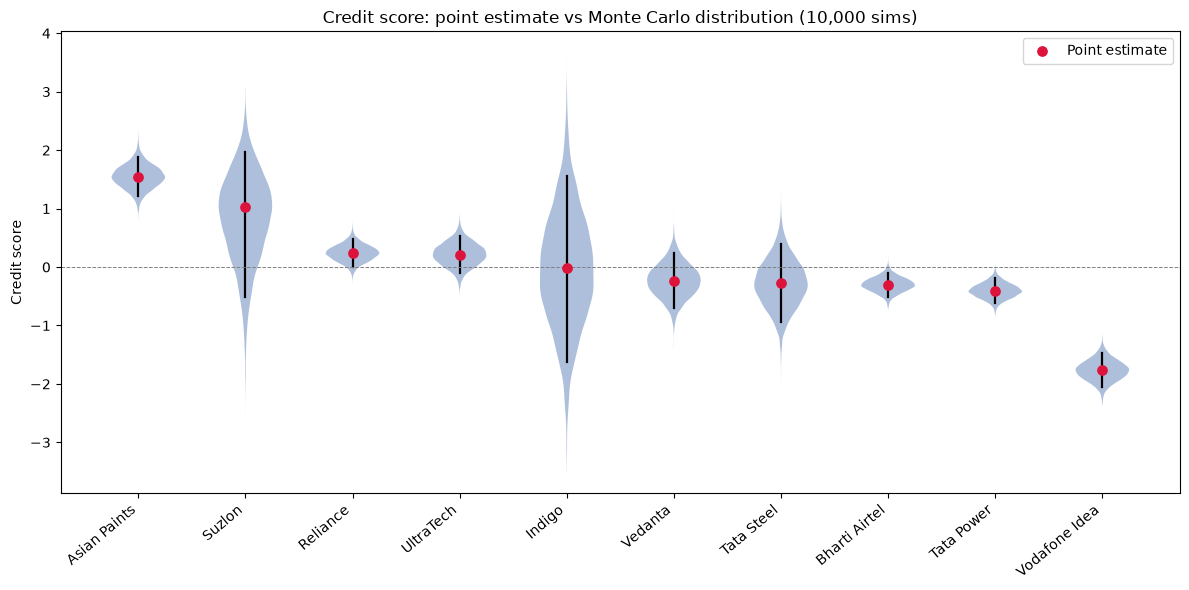

In [14]:
import matplotlib.pyplot as plt

order = d.sort_values('score', ascending=False)['Firm'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))

parts = ax.violinplot([S[f] for f in order], showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('#4C72B0')
    pc.set_alpha(0.45)

pts = [d.set_index('Firm')['score'][f] for f in order]
ax.scatter(range(1, 11), pts, color='crimson', zorder=3, s=45, label='Point estimate')

for i, f in enumerate(order, 1):
    ax.plot([i, i], [S[f].quantile(0.05), S[f].quantile(0.95)],
            color='black', lw=1.6, zorder=2)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(order, rotation=40, ha='right')
ax.set_ylabel('Credit score')
ax.set_title('Credit score: point estimate vs Monte Carlo distribution (10,000 sims)')
ax.axhline(0, color='grey', ls='--', lw=0.7)
ax.legend()
plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150)
plt.show()

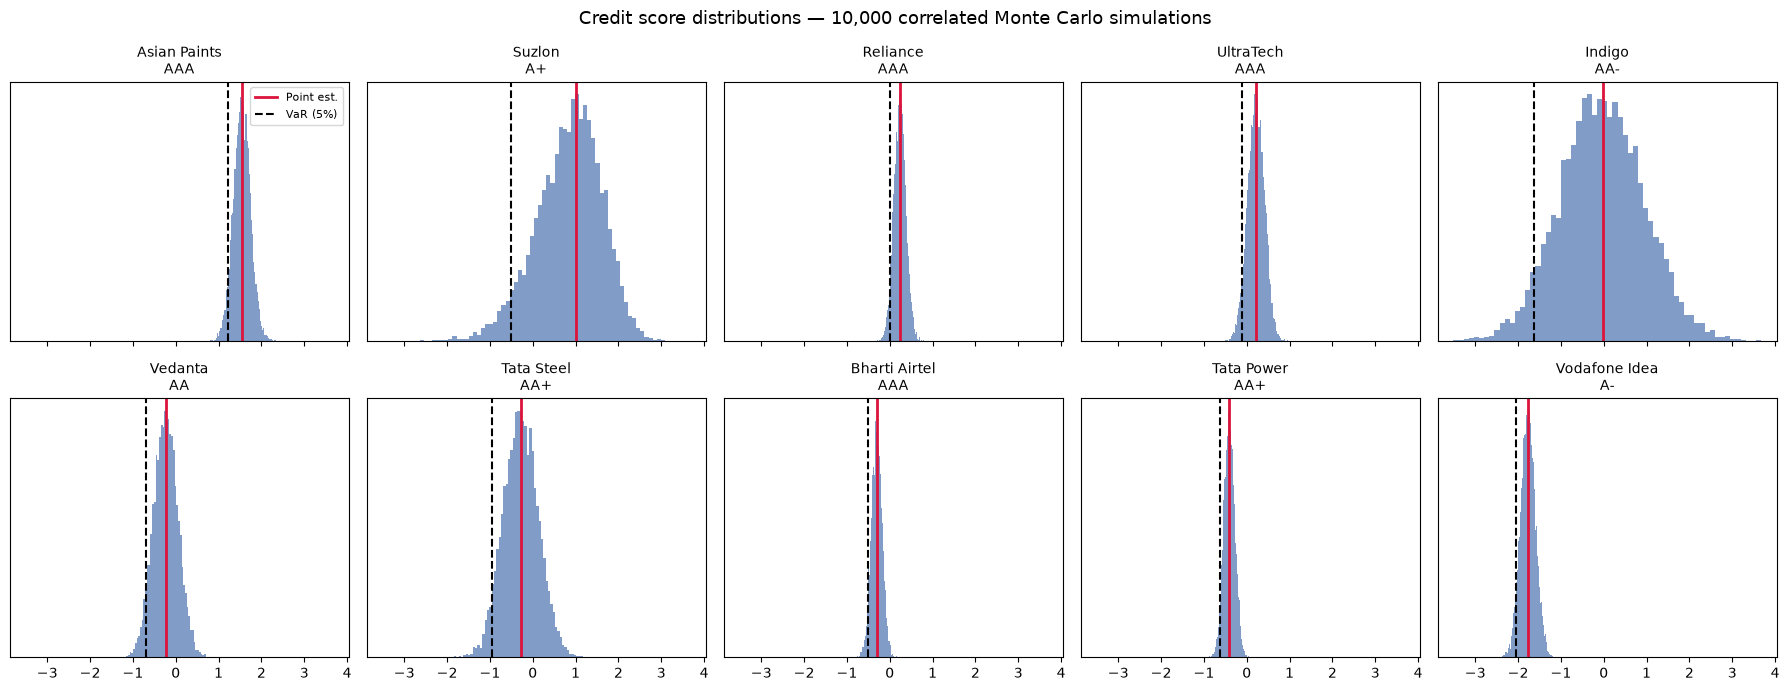

In [15]:
order = d.sort_values('score', ascending=False)['Firm'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)

for ax, fm in zip(axes.flatten(), order):
    ax.hist(S[fm], bins=60, color='#4C72B0', alpha=0.7)
    ax.axvline(d.set_index('Firm')['score'][fm], color='crimson', lw=2, label='Point est.')
    ax.axvline(S[fm].quantile(0.05), color='black', ls='--', lw=1.5, label='VaR (5%)')
    ax.set_title(f"{fm}\n{d.set_index('Firm')['credit_rating'][fm]}", fontsize=10)
    ax.set_yticks([])

axes[0,0].legend(fontsize=8)
fig.suptitle('Credit score distributions — 10,000 correlated Monte Carlo simulations', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_histograms.png', dpi=150)
plt.show()

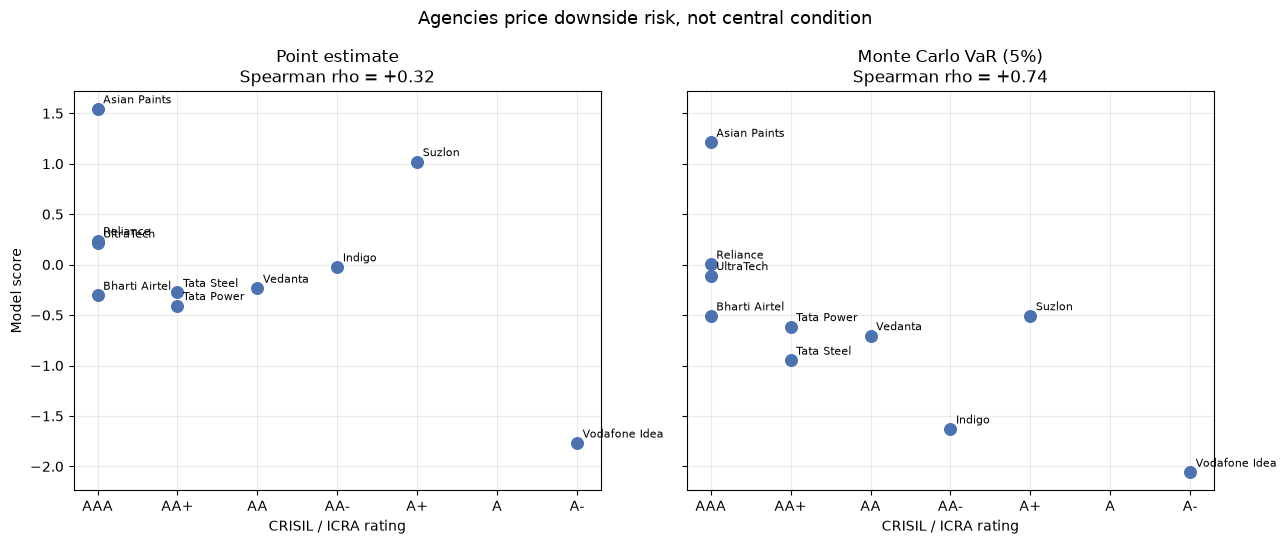

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax, (col, label, rho) in zip(axes, [
    (var.M2_point, 'Point estimate', 0.320),
    (var.VaR_5,    'Monte Carlo VaR (5%)', 0.740)
]):
    ax.scatter(var.rating_num, col, s=70, color='#4C72B0', zorder=3)
    for fm in var.index:
        ax.annotate(fm, (var.rating_num[fm], col[fm]),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')
    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(['AAA','AA+','AA','AA-','A+','A','A-'])
    ax.set_xlabel('CRISIL / ICRA rating')
    ax.set_title(f'{label}\nSpearman rho = {rho:+.2f}')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Model score')
fig.suptitle('Agencies price downside risk, not central condition', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_validation.png', dpi=150)
plt.show()

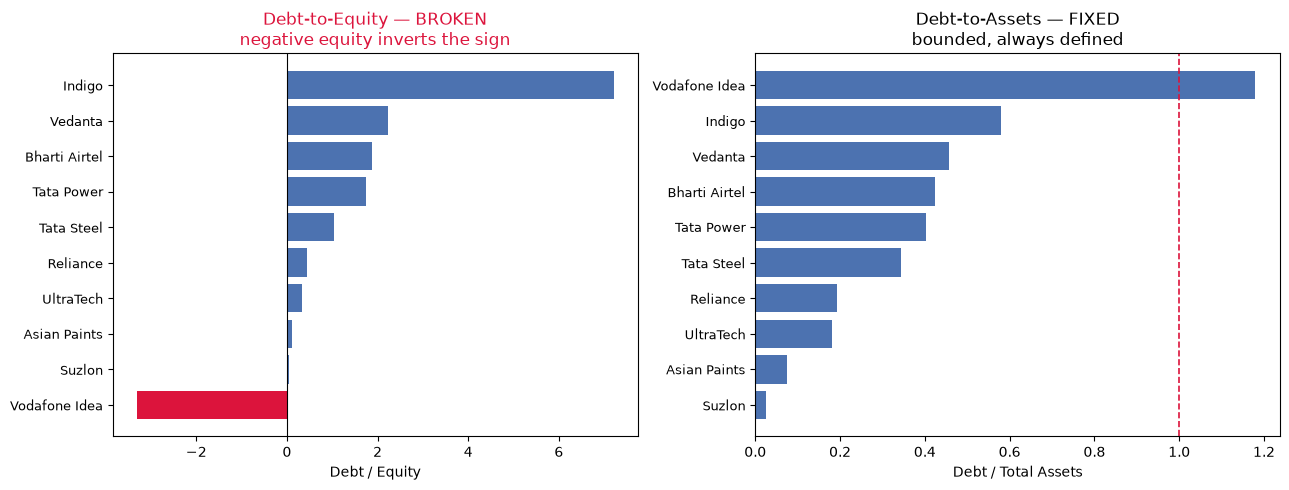

In [17]:
d25 = df[df.Year == 2025].set_index('Firm')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: D/E -- broken
o1 = d25.debt_equity.sort_values()
cols = ['crimson' if v < 0 else '#4C72B0' for v in o1]
axes[0].barh(range(len(o1)), o1.values, color=cols)
axes[0].set_yticks(range(len(o1)))
axes[0].set_yticklabels(o1.index, fontsize=9)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Debt / Equity')
axes[0].set_title('Debt-to-Equity — BROKEN\nnegative equity inverts the sign', color='crimson')

# RIGHT: D/A -- fixed
o2 = d25.debt_assets.sort_values()
axes[1].barh(range(len(o2)), o2.values, color='#4C72B0')
axes[1].set_yticks(range(len(o2)))
axes[1].set_yticklabels(o2.index, fontsize=9)
axes[1].axvline(1.0, color='crimson', ls='--', lw=1.2)
axes[1].set_xlabel('Debt / Total Assets')
axes[1].set_title('Debt-to-Assets — FIXED\nbounded, always defined')

plt.tight_layout()
plt.savefig('fig4_metric_failure.png', dpi=150)
plt.show()

In [23]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


## Module 5: Merton Distance-to-Default

This is a second, fully independent way to measure credit risk — built from **market data** instead of accounting ratios. The idea, from **Merton (1974)**, is that a company's equity behaves like a **call option on its assets**. If the assets are worth more than the debt, shareholders keep the difference. If they aren't, limited liability means shareholders just walk away rather than cover the shortfall.

This cell pulls the market inputs I need: a year of **daily share prices** per firm, which give me the **equity volatility** and **market capitalisation**. The debt figure reuses the borrowings I already collected. The one thing I watch closely here is **units** — market cap has to be converted to crores so it lines up with the debt.

In [25]:
import yfinance as yf
import pandas as pd, numpy as np

tickers = {
    'Reliance':'RELIANCE.NS', 'UltraTech':'ULTRACEMCO.NS', 'Asian Paints':'ASIANPAINT.NS',
    'Bharti Airtel':'BHARTIARTL.NS', 'Tata Steel':'TATASTEEL.NS', 'Vedanta':'VEDL.NS',
    'Tata Power':'TATAPOWER.NS', 'Indigo':'INDIGO.NS', 'Suzlon':'SUZLON.NS', 'Vodafone Idea':'IDEA.NS'
}

rows = []
for firm, tk in tickers.items():
    t = yf.Ticker(tk)
    px = t.history(period='1y')['Close'].dropna()
    if len(px) < 100:
        print(f"⚠️ {firm}: only {len(px)} prices — CHECK TICKER")
        continue
    ret = np.log(px / px.shift(1)).dropna()
    sigma_E = ret.std() * np.sqrt(252)
    price = px.iloc[-1]

    shares = None
    try:
        shares = t.info.get('sharesOutstanding')
    except Exception:
        pass
    if not shares:
        try:
            shares = t.fast_info['shares']
        except Exception:
            shares = np.nan

    mcap_cr = (shares * price) / 1e7 if shares and not np.isnan(shares) else np.nan
    flag = '' if (shares and not np.isnan(shares)) else ' ⚠️ NO SHARE COUNT'
    rows.append({'Firm':firm, 'price':round(price,1), 'sigma_E':round(sigma_E,3),
                 'shares_cr':round(shares/1e7,1) if shares and not np.isnan(shares) else np.nan,
                 'mcap_cr':round(mcap_cr,0) if not np.isnan(mcap_cr) else np.nan})
    if flag: print(f"{firm}{flag}")

inp = pd.DataFrame(rows).set_index('Firm')
print(inp.to_string())

                 price  sigma_E  shares_cr    mcap_cr
Firm                                                 
Reliance        1327.2    0.204     1353.2  1796030.0
UltraTech      11727.0    0.228       29.4   344973.0
Asian Paints    2689.0    0.237       95.9   257779.0
Bharti Airtel   1908.8    0.195      623.8  1190623.0
Tata Steel       185.9    0.269     1247.2   231839.0
Vedanta          253.1    1.111      390.5    98811.0
Tata Power       377.2    0.207      319.5   120544.0
Indigo          5248.5    0.333       38.7   202942.0
Suzlon            52.0    0.321     1374.4    71454.0
Vodafone Idea     13.7    0.488    10834.3   148863.0


In [19]:
inp.to_csv('merton_inputs.csv')

In [20]:
debt = df[df.Year == 2025].set_index('Firm')['Borrowings']   
merton = inp.join(debt).rename(columns={'Borrowings': 'D'})
merton['E'] = merton['mcap_cr']        
merton['sigma_E'] = merton['sigma_E']  

print(merton[['E', 'D', 'sigma_E']].round(0).to_string())

                       E       D  sigma_E
Firm                                     
Reliance       1796030.0  374313      0.0
UltraTech       344973.0   24102      0.0
Asian Paints    257779.0    2290      0.0
Bharti Airtel  1190623.0  213642      0.0
Tata Steel      231839.0   94801      0.0
Vedanta          98811.0   91479      1.0
Tata Power      120544.0   62866      0.0
Indigo          202942.0   67088      0.0
Suzlon           71454.0     323      0.0
Vodafone Idea   148863.0  233229      0.0


### Solving the model

With the inputs ready, I set up the two equations at the core of the Merton model. The first is **Black-Scholes**, treating equity as a call option on the firm's assets. The second links the firm's **equity volatility to its asset volatility**. Between them I have two equations and two unknowns — the asset value and the asset volatility — which I solve together numerically.

I used the equity-to-asset volatility relationship as an **established result from the Merton framework** rather than deriving it from scratch. Once I have the asset value and volatility, the **distance-to-default** is just how many standard deviations of asset value sit between the firm and its debt, and the probability of default follows from that.

In [21]:
from scipy.stats import norm
from scipy.optimize import fsolve

merton_df = merton   # rename to avoid clash with the function
r, T = 0.07, 1.0

def merton(E, sigma_E, D):
    def eqns(x):
        V, sA = x
        d1 = (np.log(V/D) + (r + 0.5*sA**2)*T) / (sA*np.sqrt(T))
        d2 = d1 - sA*np.sqrt(T)
        return [V*norm.cdf(d1) - D*np.exp(-r*T)*norm.cdf(d2) - E,
                sA*V*norm.cdf(d1) - sigma_E*E]
    V, sA = fsolve(eqns, [E+D, sigma_E*E/(E+D)])
    DD = (np.log(V/D) + (r - 0.5*sA**2)*T) / (sA*np.sqrt(T))
    return round(V,0), round(sA,3), round(DD,2), round(norm.cdf(-DD)*100,4)

mres = pd.DataFrame(
    {fm: merton(*merton_df.loc[fm, ['E','sigma_E','D']]) for fm in merton_df.index},
    index=['V','sigma_A','DD','PD_%']
).T.sort_values('DD', ascending=False)

print(mres.to_string())

                       V  sigma_A     DD     PD_%
Asian Paints    259914.0    0.235  20.31   0.0000
Suzlon           71755.0    0.320  16.96   0.0000
UltraTech       367446.0    0.214  12.95   0.0000
Bharti Airtel  1389821.0    0.167  11.55   0.0000
Reliance       2145037.0    0.171  10.55   0.0000
Tata Power      179160.0    0.139   7.95   0.0000
Tata Steel      320231.0    0.195   6.51   0.0000
Indigo          265494.0    0.255   5.55   0.0000
Vodafone Idea   366247.0    0.199   2.52   0.5867
Vedanta         178878.0    0.663   0.79  21.5754


### Validating the Merton model

This checks the **market-based Merton model** against the agency ratings. Distance-to-default generally falls as ratings get worse, so the two broadly line up.

Two firms stand out. **Suzlon** has a high distance-to-default but only an A+ rating — Merton sees its current debt-free balance sheet but has no memory of its past default, which the agencies still weigh. **Vedanta** sits lowest despite an AA rating, because its equity is very volatile and Merton reads that as being close to default.

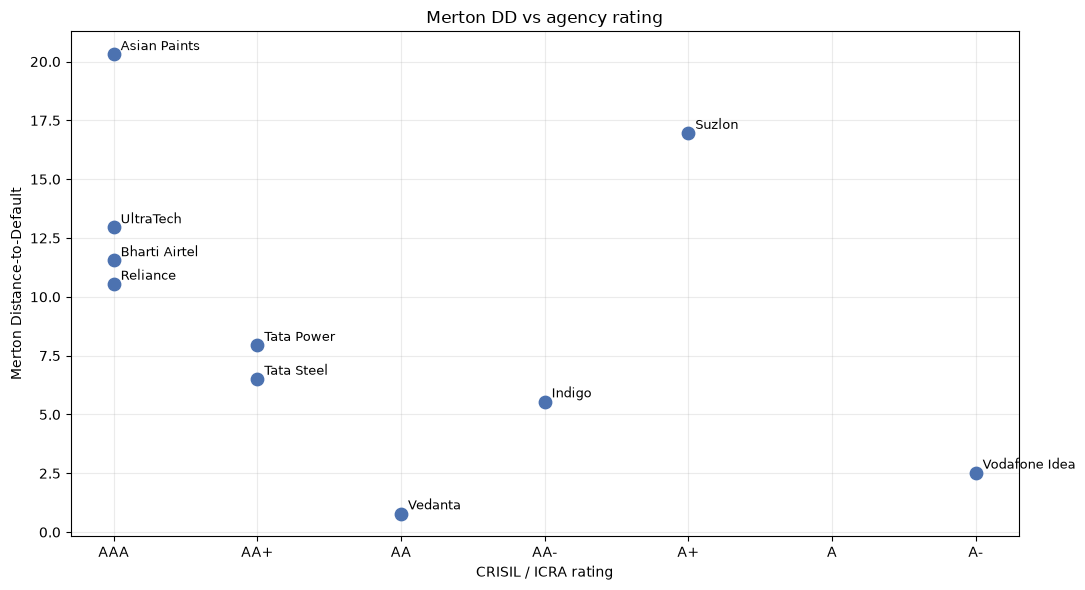

In [22]:
scale = {'AAA':1, 'AA+':2, 'AA':3, 'AA-':4, 'A+':5, 'A':6, 'A-':7}
ratings = df[df.Year==2025].set_index('Firm')['credit_rating']

fig, ax = plt.subplots(figsize=(11, 6))
x = ratings[mres.index].map(scale)
ax.scatter(x, mres.DD, s=80, color='#4C72B0', zorder=3)

for fm in mres.index:
    ax.annotate(fm, (scale[ratings[fm]], mres.DD[fm]),
                fontsize=9, xytext=(5, 3), textcoords='offset points')

ax.set_xticks(range(1, 8))
ax.set_xticklabels(['AAA','AA+','AA','AA-','A+','A','A-'])
ax.set_xlabel('CRISIL / ICRA rating')
ax.set_ylabel('Merton Distance-to-Default')
ax.set_title('Merton DD vs agency rating')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('fig5_merton.png', dpi=150)
plt.show()